# 1. (0,2P) Carga del dataset

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets
 
# Muestra la cabercera de variables predictoras
print(X.head())

# Muestra la cabecera variable a predecir
print(y.head())

# Muestra los valores de la variable a predecir. Ten en cuenta que son nombres. 
print(y['class'].unique())


   sepal length  sepal width  petal length  petal width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
         class
0  Iris-setosa
1  Iris-setosa
2  Iris-setosa
3  Iris-setosa
4  Iris-setosa
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


# Dataset Iris — Significado de las variables

El dataset **Iris** contiene mediciones de flores de tres especies de lirios. Cada fila representa una flor y cada columna una característica numérica medida en centímetros.

## Variables (features)

| Variable | Descripción | Unidad |
|---------|-------------|--------|
| **sepal length (cm)** | Longitud del sépalo | centímetros |
| **sepal width (cm)** | Ancho del sépalo | centímetros |
| **petal length (cm)** | Longitud del pétalo | centímetros |
| **petal width (cm)** | Ancho del pétalo | centímetros |

### ¿Qué es un sépalo?
Los **sépalos** son las hojas externas de la flor que protegen el capullo cuando está cerrado.

### ¿Qué es un pétalo?
Los **pétalos** son las partes de la flor que suelen ser coloridas y ayudan a atraer polinizadores.

---

## Variable objetivo (si se usa)

Aunque en **K-means no se utiliza**, el dataset original incluye la especie de la flor:

| Valor | Especie |
|------|---------|
| 0 | Iris setosa |
| 1 | Iris versicolor |
| 2 | Iris virginica |

---

## Resumen

- Total de muestras: **150 flores**
- Número de variables numéricas: **4**
- Todas las variables son **continuas** y están en **la misma unidad (cm)**, lo que facilita aplicar K-means (aunque siempre es recomendable escalar).


## (0,3) EDA sobre el dataset Iris

In [6]:
# a. Muestra información sobre el dataset: variables, tipos, etc.
df = pd.DataFrame(X)
df[y.columns] = y

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
# b. Identifica y muestra numéricamente los valores NaN de este dataset en orden ascendente.
nulos = df.isna().sum().sort_values(ascending=True)
nulos

sepal length    0
sepal width     0
petal length    0
petal width     0
class           0
dtype: int64

In [8]:
# c. Muestra el nombre de las variables predictoras
predictoras = X.columns # lista de las variables predictoras. 
print(predictoras)

Index(['sepal length', 'sepal width', 'petal length', 'petal width'], dtype='object')


## 2. (0,5P) Análisis gráfico mediante histogramas y boxplots

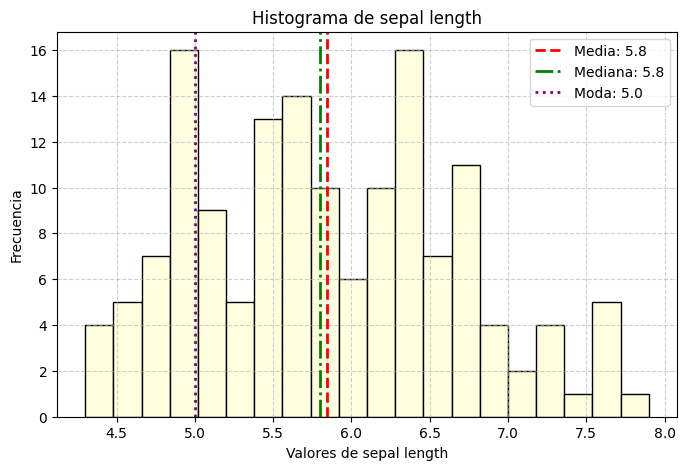

In [9]:
# a. Construye una función que, dado un dataframe y una cadena con el nombre de una variable, muestre un histograma de una variable predictora,
# y líneas de colores para representar la media, la mediana y la moda.
# Llama a la función con alguna variable predictiva y muestra el resultado.
def histograma(df, variable):    

    x = df[variable]

    media = x.mean() 
    mediana = x.median()   
    moda = x.mode()[0]          
    asimetria = x.skew()        

    plt.figure(figsize=(8,5)) 
    plt.hist(x,  
             bins=20,  
             color='lightyellow', 
             edgecolor='black' 
            )  

    plt.axvline(media, color='red', linestyle='--', linewidth=2, 
                label=f'Media: {media:.1f}')
    plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, 
                label=f'Mediana: {mediana:.1f}')
    plt.axvline(moda, color='purple', linestyle=':', linewidth=2, 
                label=f'Moda: {moda:.1f}')

    plt.title(f'Histograma de {variable}')
    plt.xlabel(f'Valores de {variable}')
    plt.ylabel('Frecuencia')
    plt.legend()                                      
    plt.grid(True, linestyle='--', alpha=0.6)           

    plt.show()                                         

histograma(df,'sepal length') 

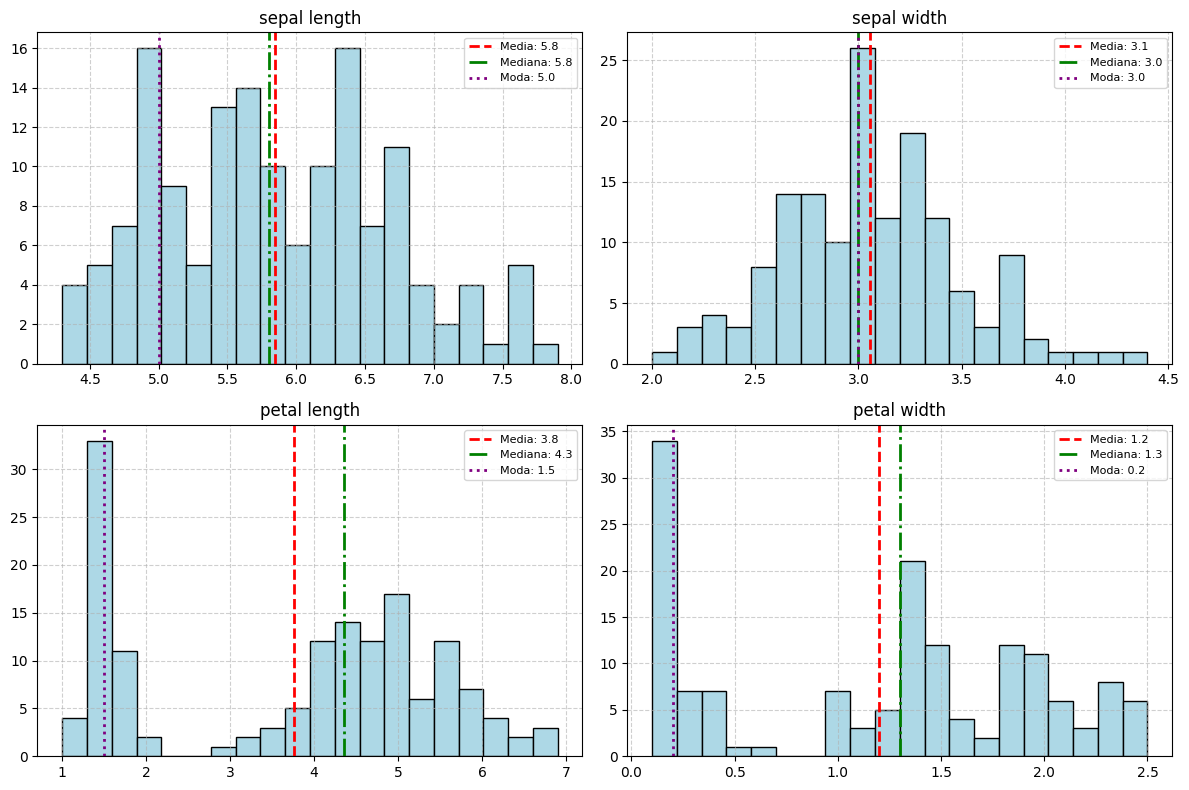

In [ ]:
# b. Construye una función -llamada histogramas- que muestre los histogramas de las variables de este dataset.
# En este caso, Los argumentos de la función son: el conjunto de variables predictivas y una lista con los nombres de estas variables.
# Llama a la función anterior y muestra los histogramas de las variables predictivas del dataset.
import matplotlib.pyplot as plt
import math


def histogramas(df, variables):
    """
    Crea una rejilla de histogramas con medidas estadísticas,  ajustando automáticamente el número de filas y columnas.
    """

    n_vars = len(variables)
    
    columnas = math.ceil(math.sqrt(n_vars))
    

    filas = math.ceil(n_vars / columnas)  
   
  
    fig, axes = plt.subplots(filas, columnas,figsize=(6*columnas, 4*filas) )
 
    axes = axes.flatten()

    for i, variable in enumerate(variables):
        ax = axes[i]
        x = df[variable].dropna()  

        media = x.mean()
        mediana = x.median()
        moda = x.mode()[0] 

        ax.hist(x, bins=20, color='lightblue', edgecolor='black')
        ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.1f}') 
        ax.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {mediana:.1f}') 
        ax.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.1f}') 

        ax.set_title(variable, fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.6)

    for j in range(i+1, len(axes)):
        axes[j].axis('off') 
    
    plt.tight_layout()
    plt.show()

histogramas(df,predictoras)

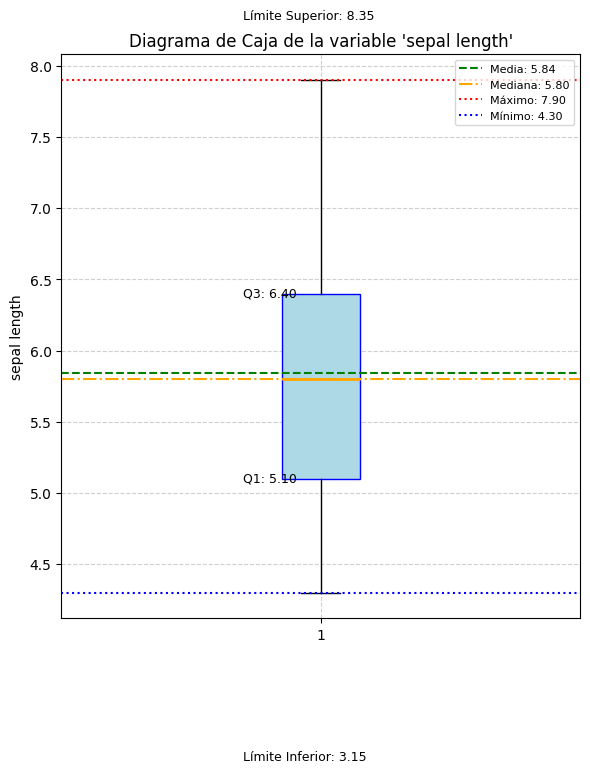

{'Q1': 5.1,
 'Q3': 6.4,
 'median': 5.8,
 'mean': 5.843333333333334,
 'min': 4.3,
 'max': 7.9,
 'IQR': 1.3000000000000007,
 'lim_inf': 3.1499999999999986,
 'lim_sup': 8.350000000000001}

In [14]:
# c. Construye una función que, dado un conjunto de datos y una cadena con el nombre de una variable, muestre un boxplot de esa variable,
# líneas de colores para representar la media, la mediana, la moda y valores de máximo y mínimo de la variable.
# Llama a la función con alguna variable predictiva y muestra el resultado. 
def boxplot_variable(df, var):
    """
    Representa un diagrama de caja (boxplot) para una variable numérica y calcula sus principales estadísticas descriptivas.

    Parámetros
    ----------
    df : pandas.DataFrame        #Conjunto de datos.
    var : str                    #Nombre de la columna numérica a analizar.
    Retorna
    -------
    stats : dict                 #Diccionario con las estadísticas calculadas.
    """ 
    plt.figure(figsize=(6, 8))
    plt.boxplot(df[var].dropna(),
                vert=True,
                patch_artist=True,
                boxprops=dict(facecolor="lightblue", color="blue"), 
                medianprops=dict(color="orange", linewidth=2))
    
    plt.title(f"Diagrama de Caja de la variable '{var}'")
    plt.ylabel(var)

    stats = {}
    stats['Q1'] = df[var].quantile(0.25)
    stats['Q3'] = df[var].quantile(0.75)
    stats['median'] = df[var].median()
    stats['mean'] = df[var].mean()
    stats['min'] = df[var].min()
    stats['max'] = df[var].max()
    stats['IQR'] = stats['Q3'] - stats['Q1']
    stats['lim_inf'] = stats['Q1'] - 1.5 * stats['IQR']
    stats['lim_sup'] = stats['Q3'] + 1.5 * stats['IQR']

    lineas = {
        'Media': ('mean', 'green', '--'),
        'Mediana': ('median', 'orange', '-.'),
        'Máximo': ('max', 'red', ':'),
        'Mínimo': ('min', 'blue', ':')
    }

    for etiqueta, (clave, color, estilo) in lineas.items():
        plt.axhline(y=stats[clave], color=color, linestyle=estilo,
                    label=f"{etiqueta}: {stats[clave]:.2f}")

    textos = {
        'Q1': stats['Q1'],
        'Q3': stats['Q3'],
        'Límite Inferior': stats['lim_inf'],
        'Límite Superior': stats['lim_sup']
    }

    for etiqueta, valor in textos.items():
        plt.text(0.85, valor, f"{etiqueta}: {valor:.2f}",
                 color='black', fontsize=9, va='center')

    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return stats

boxplot_variable(df, 'sepal length')



## 3. (1P) Análisis gráfico del dataset por clase

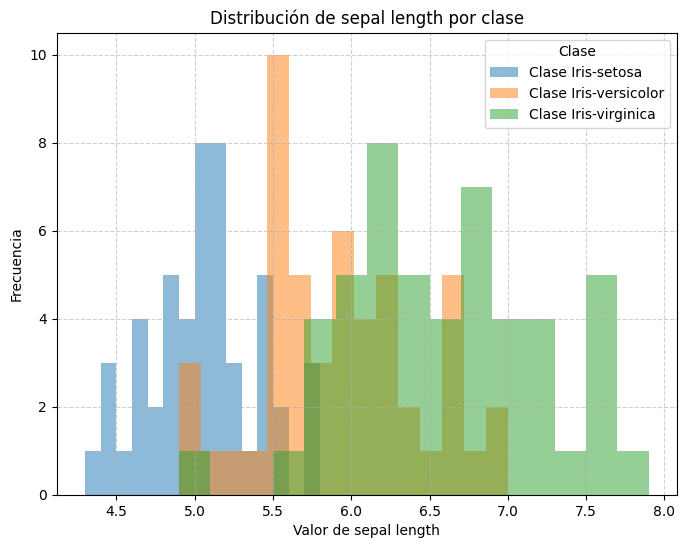

In [25]:
#
#  a. Gráficos y análisis de distribución de una variable por clase. Histograma.
#     Modifica la función 'histograma_clase' para que:
#                -Dado un dataframe df
#                -Una cadena con el nombre de una variable predictoras
#     Muestre el histograma de la variable por clase:

# Nota: tened en cuenta que la función recibe y trabaja internamente con un dataframe df. Debes construirlo a partir de X e y 
# antes de modificar el código de la función. Utiliza la función iloc() para acceder a la columna a predecir del dataframe df

# Construye el dataframe df a partir de X e y

# Escribe la función 'histograma_clase' modificada
def histograma_clase(df, variable):
    
    target = df.iloc[:,-1].name
    plt.figure(figsize=(8, 6))   
    clases = df[target].unique() 

    for i, c in enumerate(clases):
        mascara = df[target] == c 
        x = df[mascara][variable] 

        plt.hist(x,                    
                 bins=15,              
                 alpha=0.5,             
                 label=f'Clase {c}'    
                )

    plt.title(f'Distribución de {variable} por clase')
    plt.xlabel(f'Valor de {variable}')
    plt.ylabel('Frecuencia')
    plt.legend(title='Clase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
# llama a la función y muestra el histograma
histograma_clase(df, 'sepal length')

In [26]:
df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


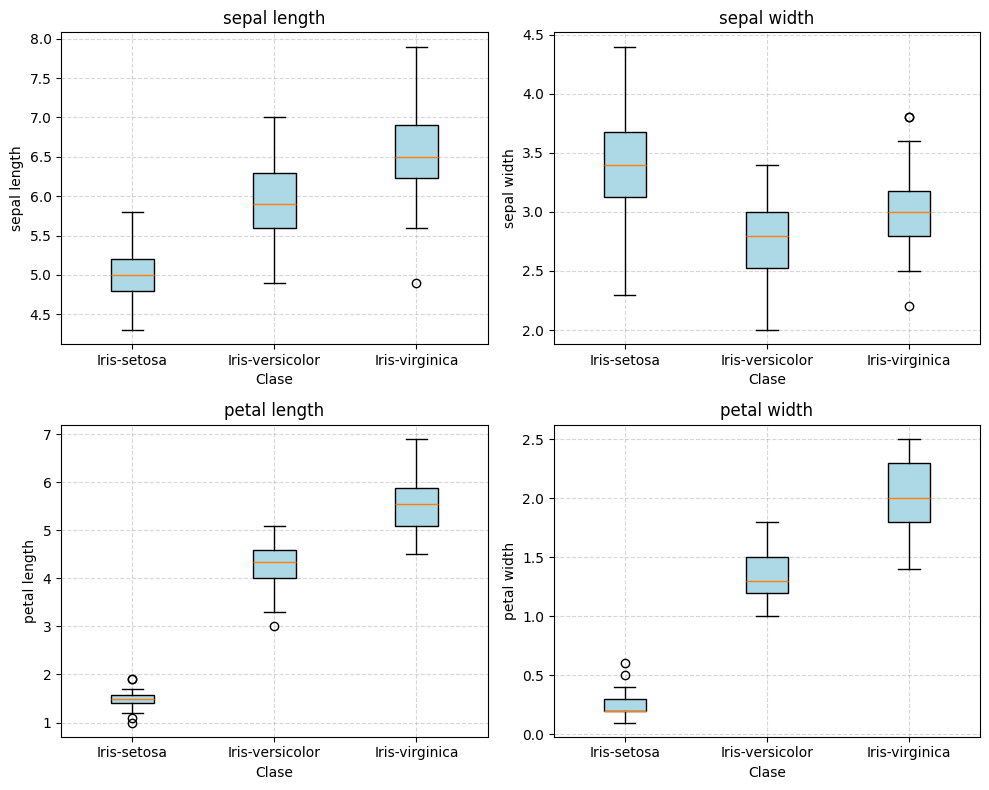

In [27]:
#
#  b. Gráficos y análisis de distribución de una variable por clase. Boxplots por clase.
#     Modifica la función 'boxplots_clase' para que:
#                -Dado un dataframe df
#                -Una cadena con el nombre de una variable predictoras
#     Muestre los boxplots de las variable por clase:

# Nota: tened en cuenta que la función recibe y trabaja internamente con un dataframe df. Debes construirlo a partir de X e y 
# antes de modificar el código de la función. Utiliza la función iloc() para acceder a la columna a predecir del dataframe df

# Construye el dataframe df a partir de X e y

# Escribe la función 'boxplots_clase' modificada
import matplotlib.pyplot as plt
import math

def boxplots_clase(df, variables):
    """
    Dibuja, en una rejilla de subplots, boxplots de varias variables numéricas diferenciadas por clase (columna 'target').
    
    Parámetros
    ----------
    df : pandas.DataFrame        #DataFrame con los datos.
    variables : list             #Lista de nombres de columnas numéricas a representar.
    target : str                 #Nombre de la columna de clase (por defecto 'target').
    """

    target = df.iloc[:,-1].name
    clases = df[target].unique() 
    num_variables = len(variables)  

    columnas = math.ceil(math.sqrt(num_variables))
    filas = math.ceil(num_variables / columnas)

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 4*filas))
    axes = axes.flatten()  

    for i, variable in enumerate(variables): 
        ax = axes[i]                         

        x = [df[df[target] == c][variable].dropna() for c in clases]

        ax.boxplot(
            x,
            tick_labels=clases,                  
            patch_artist=True,                   
            boxprops=dict(facecolor='lightblue') 
        )

        ax.set_title(variable)
        ax.set_xlabel('Clase')
        ax.set_ylabel(variable)
        ax.grid(True, linestyle='--', alpha=0.5)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

boxplots_clase(df, predictoras)

## 4. (1P) Gráfico 3D de 3 variables predictores del dataset

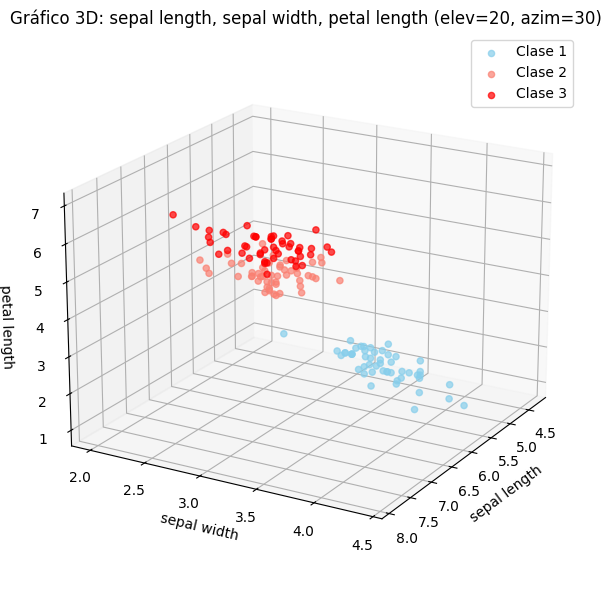

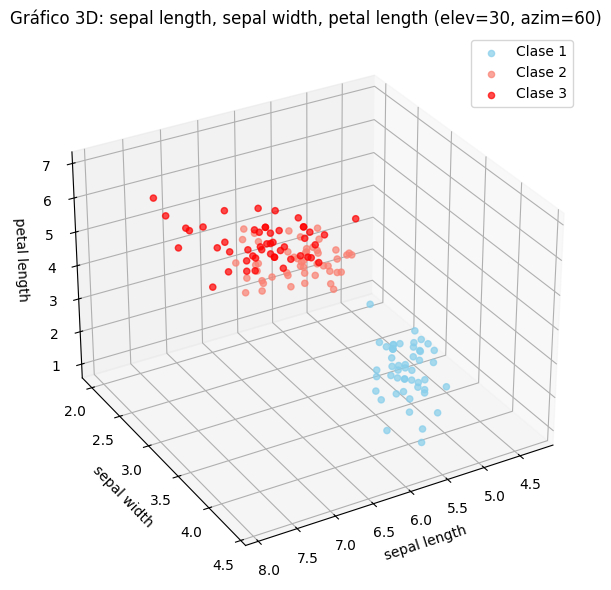

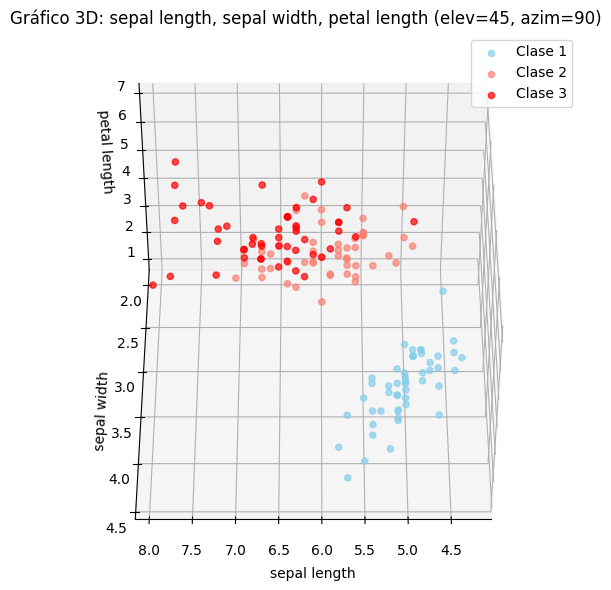

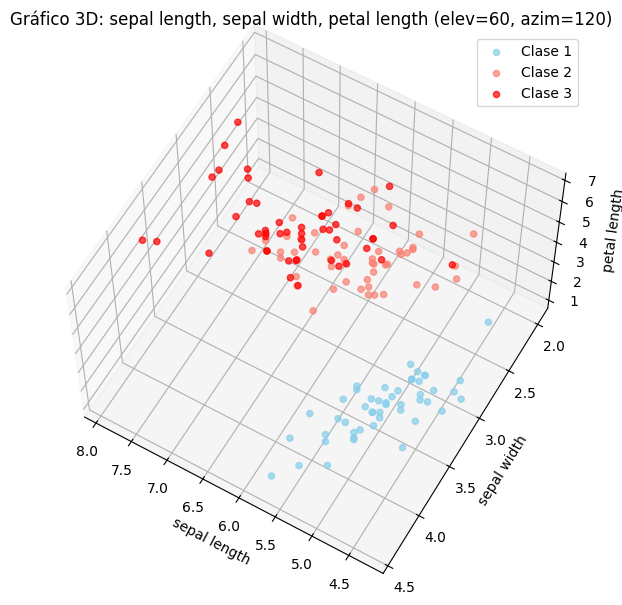

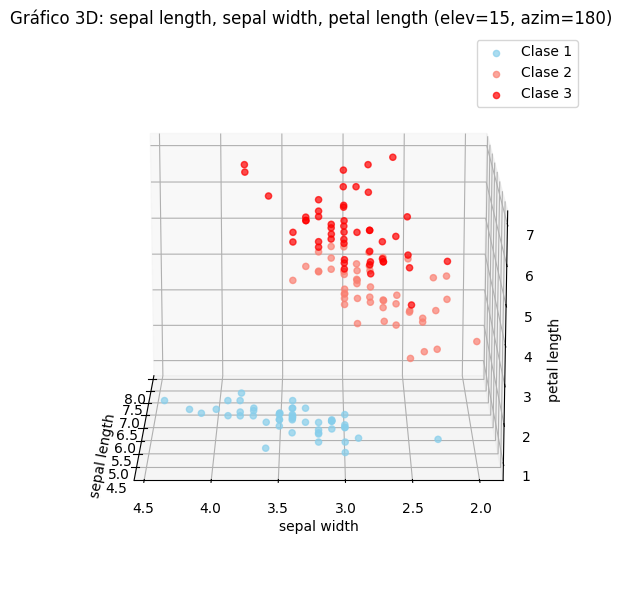

In [28]:
#

# Elige tres variables predictoras originales, represéntalas desde diferentes ángulos (5 combinaciones de azimut y altura).
# Haz esta representación mediante el uso iterativo de una función que acepte un dataframe, tres cadenas de caracteres
# cada una de las cuales contenga el nombre de una variable predictora, un valor de azimut y un valor de altura.

#
#  Gráfico 3D
# a. Elige tres variables predictoras originales, represéntalas desde diferentes ángulos (5 combinaciones de azimut y altura).
# Haz esta representación mediante el uso iterativo de una función que acepte un dataframe, tres cadenas de caracteres
# cada una de las cuales contenga el nombre de una variable predictora, un valor de azimut y un valor de altura.
# 
# Modifica la función para que acceda a la variable a predecir a través de la función iloc()!!!!
# Importante: en este dataset las clases no son números 0,1 y 2. Son nombres: 'Iris-setosa', 'Iris-versicolor' y 'Iris-virginica'

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def grafico_3d(df, x_var, y_var, z_var, elev, azim):
    """
    Dibuja un gráfico 3D de tres variables numéricas con una orientación definida.
    Parámetros:
    df    : DataFrame con los datos
    x_var : nombre de la variable para el eje X
    y_var : nombre de la variable para el eje Y
    z_var : nombre de la variable para el eje Z
    elev  : ángulo de elevación de la cámara
    azim  : ángulo de rotación (azimut)
    """
    target = df.iloc[:,-1].name
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection='3d')
    plt.title(f'Gráfico 3D: {x_var}, {y_var}, {z_var} (elev={elev}, azim={azim})')
    # Clase 1
    x0 = df[df[target] == 'Iris-setosa'][x_var]
    y0 = df[df[target] == 'Iris-setosa'][y_var]
    z0 = df[df[target] == 'Iris-setosa'][z_var]
    ax.scatter3D(x0, y0, z0, color='skyblue', alpha=0.7, label='Clase 1')
    # Clase 2
    x1 = df[df[target] == 'Iris-versicolor'][x_var]
    y1 = df[df[target] == 'Iris-versicolor'][y_var]
    z1 = df[df[target] == 'Iris-versicolor'][z_var]
    ax.scatter3D(x1, y1, z1, color='salmon', alpha=0.7, label='Clase 2')
    # Clase 3
    x1 = df[df[target] == 'Iris-virginica'][x_var]
    y1 = df[df[target] == 'Iris-virginica'][y_var]
    z1 = df[df[target] == 'Iris-virginica'][z_var]
    ax.scatter3D(x1, y1, z1, color='red', alpha=0.7, label='Clase 3')

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_zlabel(z_var)
    ax.legend()
    
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


var1, var2 , var3 = ('sepal length', 'sepal width', 'petal length')


# Gráfico 1
grafico_3d(df, var1, var2, var3, elev=20, azim=30)

# Gráfico 2
grafico_3d(df, var1, var2, var3, elev=30, azim=60)

# Gráfico 3
grafico_3d(df, var1, var2, var3 , elev=45, azim=90)

# Gráfico 4
grafico_3d(df,  var1, var2, var3 ,elev=60, azim=120)

# Gráfico 5
grafico_3d(df, var1, var2, var3, elev=15, azim=180)



## 5. (1P) Estandarización de variables predictoras

In [30]:
# Estandarizamos las variables predictoras. Recordamos que están en el objeto X, un dataframe de Pandas.
# la estandarización se realiza para que todas las variables estén en una escala comparable y el algoritmo las tenga en cuenta a todas.
# Llama al conjunto estadandarizado X_scaled.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)
# Muéstralo.
X_scaled

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

## 6. (2P) k-means

In [32]:
# a. Instancia objetos k-means desde 1 hasta 10 clústeres y entrena estos objetos k-means con el conjunto escalado.
from sklearn.cluster import KMeans
inercias = [] 
n_clusters = range(1,11) 
for n in n_clusters:
    km = KMeans(n_clusters=n,  
           init='k-means++',   
           n_init='auto',      
           max_iter=300,       
           tol=0.0001,         
           random_state=10,    
           algorithm='lloyd'   
           )
    km.fit(X_scaled)           
    inercias.append(km.inertia_)
#    Muestra las inercias para cada uno de los objetos k-means anteriores.
inercias


[600.0,
 223.73200573676345,
 142.11063713104193,
 114.68221609937967,
 91.13730688271085,
 84.12084659537993,
 72.1993057139817,
 67.27844112254647,
 56.003580138954135,
 52.46044714910792]

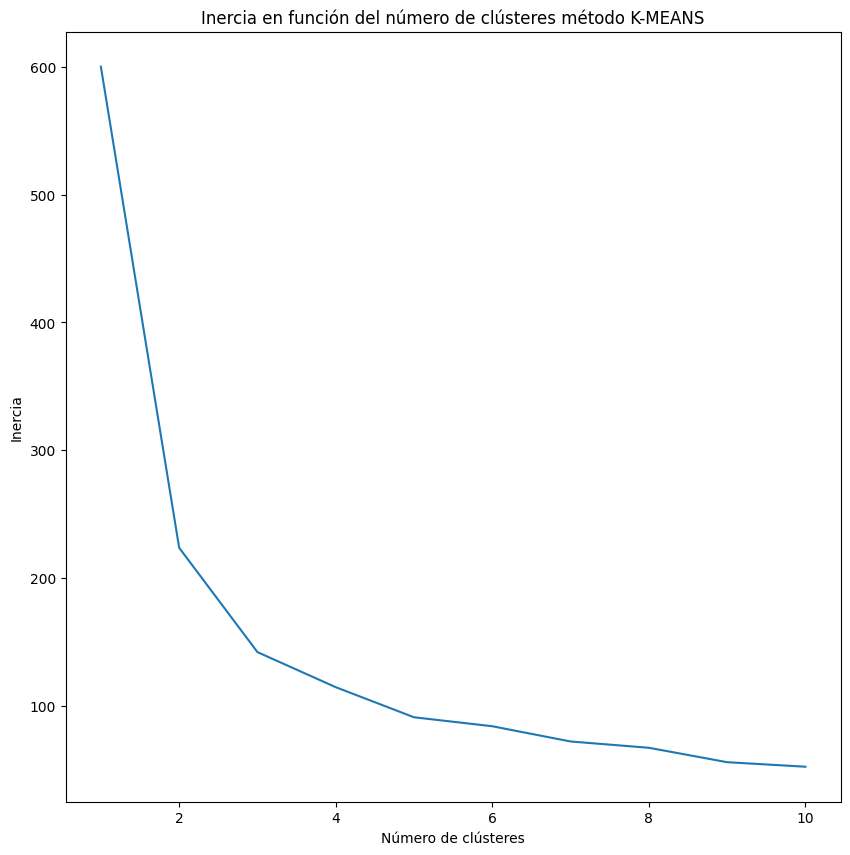

In [33]:
# b. Muestra la gráfica del codo y, en base a esta gráfica, encuentra el número de clústeres en el que estan agrupados
# los datos de este dataset.
plt.figure(figsize=(10,10))
plt.plot(n_clusters, inercias)
plt.title('Inercia en función del número de clústeres método K-MEANS')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.show()

Text(0, 0.5, 'Media índices silhouette')

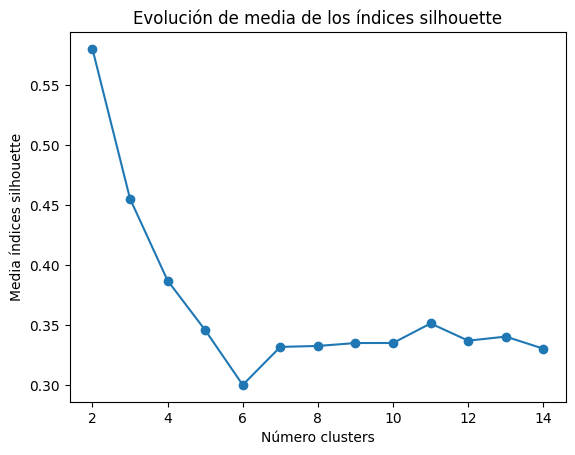

In [34]:
# c. Utiliza el método silhouette para identificar el número de clústeres en el que está agrupado este dataset.
# Recuerda que esta gráfica nos ofrece el coe7ficiente de silhouette global.
from sklearn.metrics import silhouette_samples, silhouette_score

num_clusters = range(2, 15)  
valores_medios_silhouette = []    

for n_clusters in num_clusters:
    km = KMeans(
                        init='k-means++',
                        n_clusters   = n_clusters, 
                        n_init       = 'auto', 
                        max_iter     = 300,
                        tol          = 0.0001,
                        random_state = 10,
                        algorithm    = 'lloyd'
                    )
    cluster_labels = km.fit_predict(X_scaled) 
    silhouette_medio = silhouette_score(X_scaled, cluster_labels) 
    valores_medios_silhouette.append(silhouette_medio) 
    
fig, ax = plt.subplots()
ax.plot(num_clusters, valores_medios_silhouette, marker='o') 
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette')


Para 2 clústeres el silhouette_score es 0.580184463257396 

El tamaño del cluster 0 es: 100

El tamaño del cluster 1 es: 50


Para 3 clústeres el silhouette_score es 0.45542721937148334 

El tamaño del cluster 0 es: 55

El tamaño del cluster 1 es: 49

El tamaño del cluster 2 es: 46


Para 4 clústeres el silhouette_score es 0.38724679456128813 

El tamaño del cluster 0 es: 51

El tamaño del cluster 1 es: 27

El tamaño del cluster 2 es: 49

El tamaño del cluster 3 es: 23


Para 5 clústeres el silhouette_score es 0.345972967262151 

El tamaño del cluster 0 es: 47

El tamaño del cluster 1 es: 27

El tamaño del cluster 2 es: 25

El tamaño del cluster 3 es: 23

El tamaño del cluster 4 es: 28


Para 6 clústeres el silhouette_score es 0.30034309672234183 

El tamaño del cluster 0 es: 25

El tamaño del cluster 1 es: 27

El tamaño del cluster 2 es: 23

El tamaño del cluster 3 es: 23

El tamaño del cluster 4 es: 22

El tamaño del cluster 5 es: 30


Para 7 clústeres el silhouette_score es 0.33201

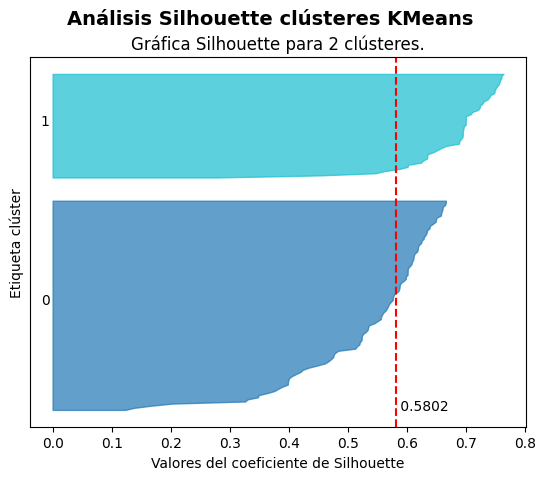

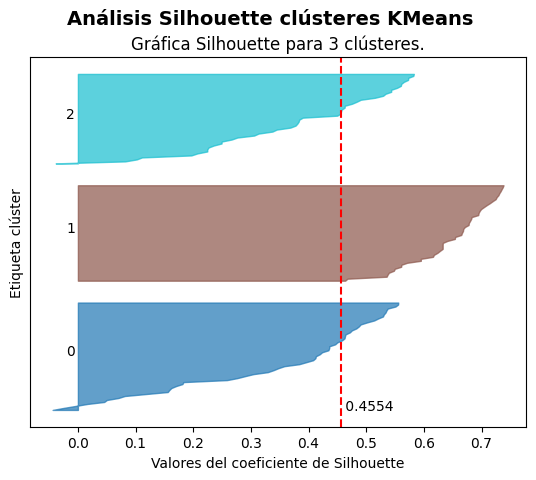

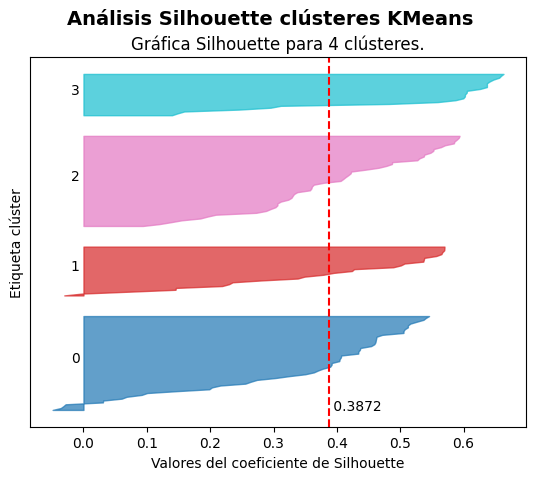

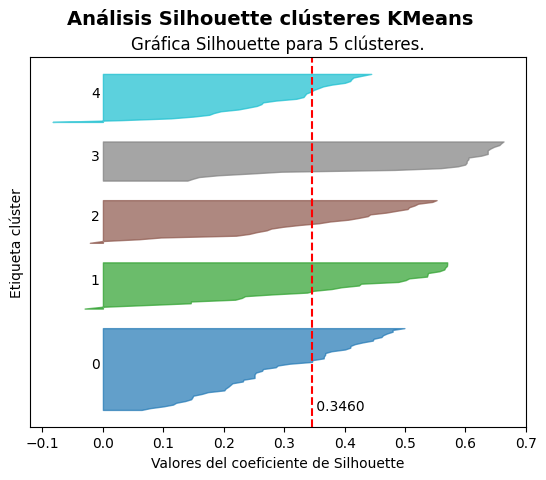

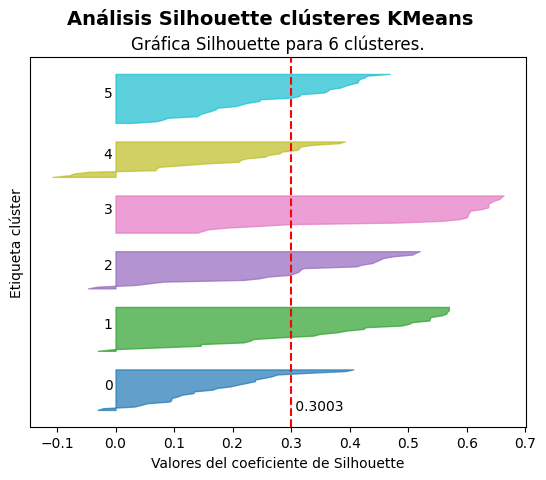

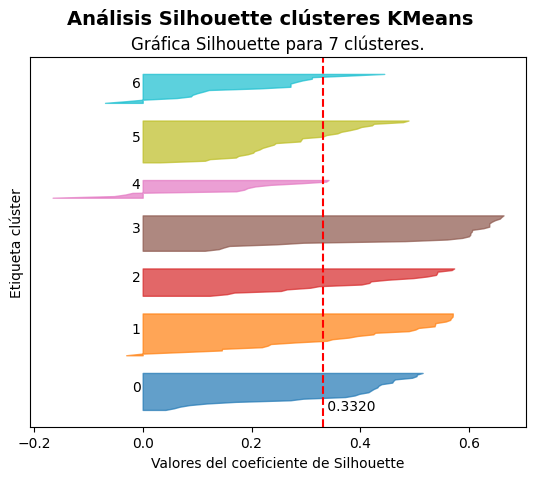

In [35]:
# d. Amplía el análisis gráfico mediante la representación de las gráficas que muestran los coeficientes de silhouette por
# cada punto de cada clúster y el coeficiente de Silhouette global para diferente número de clústeres.
# Comprueba que la información que oferecen es consistente con la información de los dos puntos anteriores.
# Muestra las gráficas.
import matplotlib.cm as cm
rango_n_clusteres = [2, 3, 4, 5, 6, 7]

for n_clusteres in rango_n_clusteres: 

    fig, ax = plt.subplots()    
    ax.set(yticks = []) 
  
    km = KMeans(n_clusters=n_clusteres, random_state=10, n_init="auto")
    cluster_labels = km.fit_predict(X_scaled) 
  
      
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels) 
   
    silhouette_medio = silhouette_score(X_scaled, cluster_labels)  
    print(
        f"\nPara {n_clusteres} clústeres el silhouette_score es {silhouette_medio} \n"
    )

    y_inf = 0  
    for i in range(n_clusteres):
       
        cluster_i_silhouette_values = sample_silhouette_values[cluster_labels == i]

        cluster_i_silhouette_values.sort()

        size_cluster_i = len(cluster_i_silhouette_values) 

        print(f'El tamaño del cluster {i} es: {size_cluster_i}\n')

        y_sup = y_inf + size_cluster_i 
        cmap = plt.get_cmap("tab10", n_clusteres)
        color = cmap(i)  

        ax.fill_betweenx(  
            np.arange(y_inf, y_sup), 
                                         
            0,                           
            cluster_i_silhouette_values,
            facecolor=color,             
            edgecolor=color,             
            alpha=0.7,                   
        )
   
        ax.text(-0.02, y_inf + 0.5 * size_cluster_i, str(i)) 
        y_inf = y_sup + 10   

    ax.set_title(f"Gráfica Silhouette para {n_clusteres} clústeres.")
    ax.set_xlabel("Valores del coeficiente de Silhouette")
    ax.set_ylabel("Etiqueta clúster")
       
    ax.axvline(x=silhouette_medio, color="red", linestyle="--")
    ax.text(silhouette_medio, 0, f' {silhouette_medio:.4f}') 
    plt.suptitle(
        "Análisis Silhouette clústeres KMeans",
        fontsize=14,
        fontweight="bold"
    )

plt.show()

## 7. (1P) Información del objeto k-means

In [36]:
#-------------------------------------------------------------------------#
#                      Información sobre los clústeres                    #
#-------------------------------------------------------------------------#
# a. Para el número de clústeres obtenido en el análisis anterior instancia un objeto k-means y enténalo con X_scaled
from sklearn.cluster import KMeans

km = KMeans(
    n_clusters=2,      
    init='k-means++', 
    n_init='auto',   
    max_iter=300,      
    tol=0.0001,       
    random_state=10,   
    algorithm='elkan' 
)
km.fit(X_scaled)
# b. hallar el número de clústeres.
print(f'Número de clústeres: {km.cluster_centers_.shape[0]}')
# c. Hallar el número de coordenadas de cada centro de clúster
print(f'\nNúmero coordenadas de cada centro de un clúster: {km.cluster_centers_.shape[1]}')
# d. hallar las coordenadas de los centroides de los clusters.
print(f'\nCoordenadas de los centroides de los clusters: {km.cluster_centers_}')
# e. hallar el número de iteraciones necesarias para la convergencia del algoritmo k-means
print(f'\nNúmero de iteraciones: {km.n_iter_}')
# f. hallar la suma de las distancias cuadradas de cada punto a su centroide más cercano.
print('Inercia (suma de las distencias al cuadrado de cada elemento de un clúster a su centroide): ',km.inertia_)
# g. Hallar Coordenadas del centroide 0. Este centroide es el centroide de los puntos del conjuntos con etiqueta 0
centroide_0 = km.cluster_centers_[0]
print(centroide_0)
# h. Puntos del dataset que tienen la etiqueta 0 asignada por k-means
cluster0_puntos = X_scaled[km.labels_ == 0]
print(cluster0_puntos)

Número de clústeres: 2

Número coordenadas de cada centro de un clúster: 4

Coordenadas de los centroides de los clusters: [[ 0.50728948 -0.4211534   0.65243918  0.62756431]
 [-1.01457897  0.84230679 -1.30487835 -1.25512862]]

Número de iteraciones: 3
Inercia (suma de las distencias al cuadrado de cada elemento de un clúster a su centroide):  223.73200573676345
[ 0.50728948 -0.4211534   0.65243918  0.62756431]
[[ 1.40150837e+00  3.37848329e-01  5.35295827e-01  2.64698913e-01]
 [ 6.74501145e-01  3.37848329e-01  4.21564419e-01  3.96171883e-01]
 [ 1.28034050e+00  1.06445364e-01  6.49027235e-01  3.96171883e-01]
 [-4.16009689e-01 -1.74477836e+00  1.37235899e-01  1.33225943e-01]
 [ 7.95669016e-01 -5.87763531e-01  4.78430123e-01  3.96171883e-01]
 [-1.73673948e-01 -5.87763531e-01  4.21564419e-01  1.33225943e-01]
 [ 5.53333275e-01  5.69251294e-01  5.35295827e-01  5.27644853e-01]
 [-1.14301691e+00 -1.51337539e+00 -2.60824029e-01 -2.61192967e-01]
 [ 9.16836886e-01 -3.56360566e-01  4.78430123e-01 

## 8. (1P) Programación de la función de Inercia.

# Ejemplo numérico de inercia en K-means para dos clústeres

Sea \(K = 2\) clusters con:

$$
C_1 = \{(1,1), (2,1)\}, \qquad C_2 = \{(4,3), (5,4)\}
$$

Y centroides ya conocidos:

$$
\mu_1 = (1.5, 1), \qquad \mu_2 = (4.5, 3.5)
$$

La inercia se define como:

$$
\text{Inercia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

---

## Cluster 1

$$
\|(1,1) - (1.5,1)\|^2
= (1-1.5)^2 + (1-1)^2
= (-0.5)^2 + 0^2
= 0.25
$$

$$
\|(2,1) - (1.5,1)\|^2
= (2-1.5)^2 + (1-1)^2
= (0.5)^2 + 0^2
= 0.25
$$

$$
\sum_{x_i \in C_1} \|x_i - \mu_1\|^2
= 0.25 + 0.25
= 0.5
$$

---

## Cluster 2

$$
\|(4,3) - (4.5,3.5)\|^2
= (4-4.5)^2 + (3-3.5)^2
= (-0.5)^2 + (-0.5)^2
= 0.25 + 0.25
= 0.5
$$

$$
\|(5,4) - (4.5,3.5)\|^2
= (5-4.5)^2 + (4-3.5)^2
= (0.5)^2 + (0.5)^2
= 0.25 + 0.25
= 0.5
$$

$$
\sum_{x_i \in C_2} \|x_i - \mu_2\|^2
= 0.5 + 0.5
= 1.0
$$

---

## Inercia total

$$
\text{Inercia}
= 0.5 + 1.0
= 1.5
$$

$$
\boxed{\text{Inercia} = 1.5}
$$


In [57]:
# A partir del ejemplo anterior y de la información sobre los clústeres, programa la función de inercia. 
# llámala 'funcion_inercia'. Esta función debe aceptar como parámetros # un objeto k-means (km) y el conjunto de variables
# predictoras escaladao X_scaled.
def funcion_inercia(km, X_scaled):
    inercia_calculada = 0
    for i in range(X_scaled.shape[0]):
        punto = X_scaled[i]
        centroide_cercano = km.cluster_centers_[km.labels_[i]]
        distancia_cuadrada = np.sum((punto - centroide_cercano) ** 2)
        inercia_calculada += distancia_cuadrada
    return inercia_calculada

inercia_total = funcion_inercia(km, X_scaled)
print(f'Inercia total: {inercia_total}')

Inercia total: 223.73200573676343


## 9. (1P) Realiza un análisis de componentes principales PCA. restringe a dos componentes.

range(1, 5)


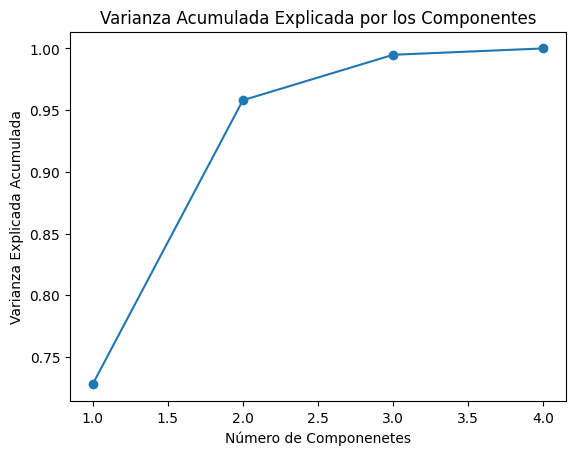

,PC0,PC1
0,-2.264542,0.505704
1,-2.086426,-0.655405
2,-2.367950,-0.318477
3,-2.304197,-0.575368
4,-2.388777,0.674767
...,...,...
145,1.870522,0.382822
146,1.558492,-0.905314
147,1.520845,0.266795
148,1.376391,1.016362


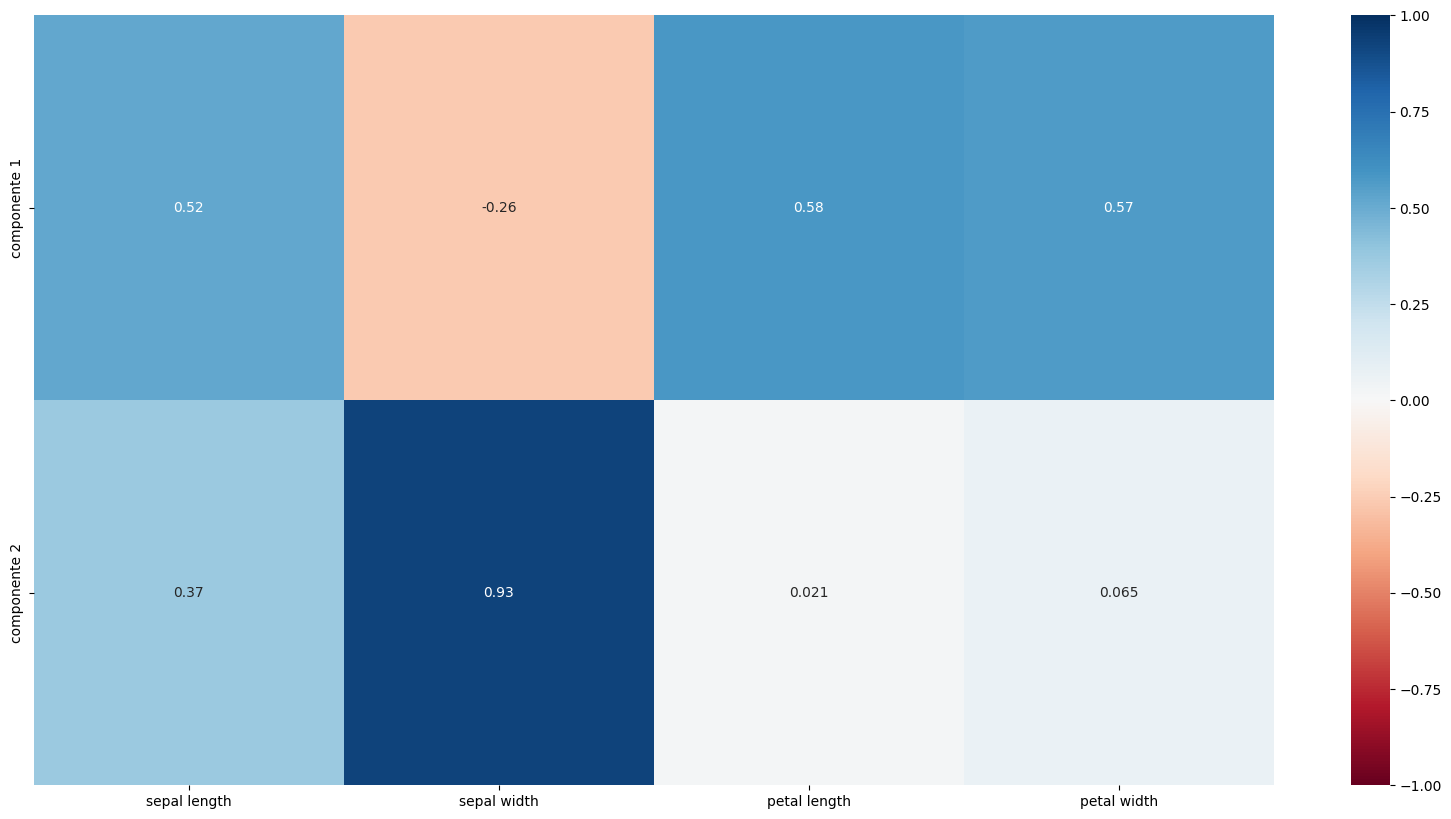

In [41]:
# a. Instancia el objeto PCA y entrénalo
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)
# b. Realiza el gráfico d ela varianza acumulada.
'''
En este gráfico, podemos ver que la mayor parte de la información (varianza) está contenida en las primeras componentes.
Por ejemplo, podríamos decidir utilizar solo las primeras 5 o 6 componentes si juntas explican más del 80% de la varianza. 
'''
num_varianzas = len(pca.explained_variance_ratio_)  
num_varianzas_acum = pca.explained_variance_ratio_.cumsum() 
num_componentes_desde_1 = range(1,len(pca.explained_variance_ratio_) + 1) 
print(num_componentes_desde_1)

plt.plot(num_componentes_desde_1,
         num_varianzas_acum,
         marker='o')

plt.title('Varianza Acumulada Explicada por los Componentes')
plt.xlabel('Número de Componenetes')
plt.ylabel('Varianza Explicada Acumulada')
plt.show()
# c. instancian un nuevo objeto PCA con dos componenetes principales. llámalo pca2
pca2 = PCA(n_components=2)
pca2.fit(X_scaled)
# d. define un dataframe en el que se visualize claramente la relación entre los componentes PCA y los atributos (predictivos) del conjunto original
df_pca2 = pd.DataFrame(data=pca2.components_,    
                       columns=X.columns.values, 
                       index=["componente 1", "componente 2"])
# e. Muestra la información anterior en for4mato de mapa de calor
plt.figure(figsize=(20,10))
mapa = sns.heatmap(df_pca2,
                  annot = True,
                  cmap = 'RdBu',
                  vmax=1,
                  vmin=-1)
# f. Transforma con el objeto pca2 el conjunto X_scaled, llámalo X_scaled_pca2. Muéstralo como un dataframe.
X_scaled_pca2= pca2.transform(X_scaled)
df_pca2 = pd.DataFrame(X_scaled_pca2, 
                      columns=['PC0', 'PC1'])
df_pca2

## 10. (1P) Muestra los dendogramas correspondientes a los diferentes método de medida de distancias entre clústeres para el conjunto X_scaled_pca2 (Single, Complete y Average)

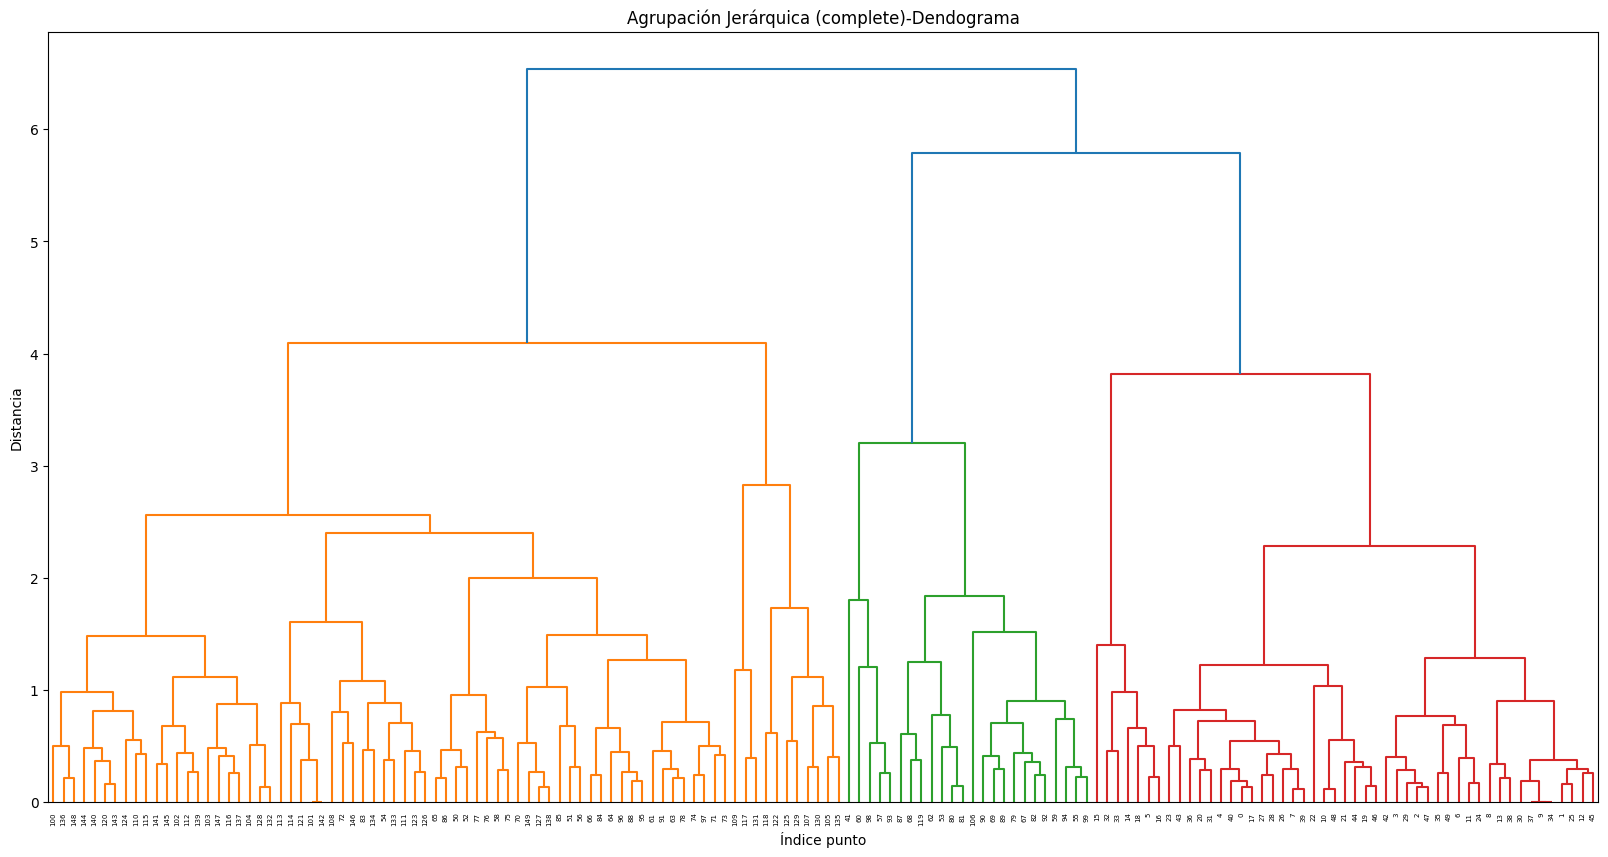

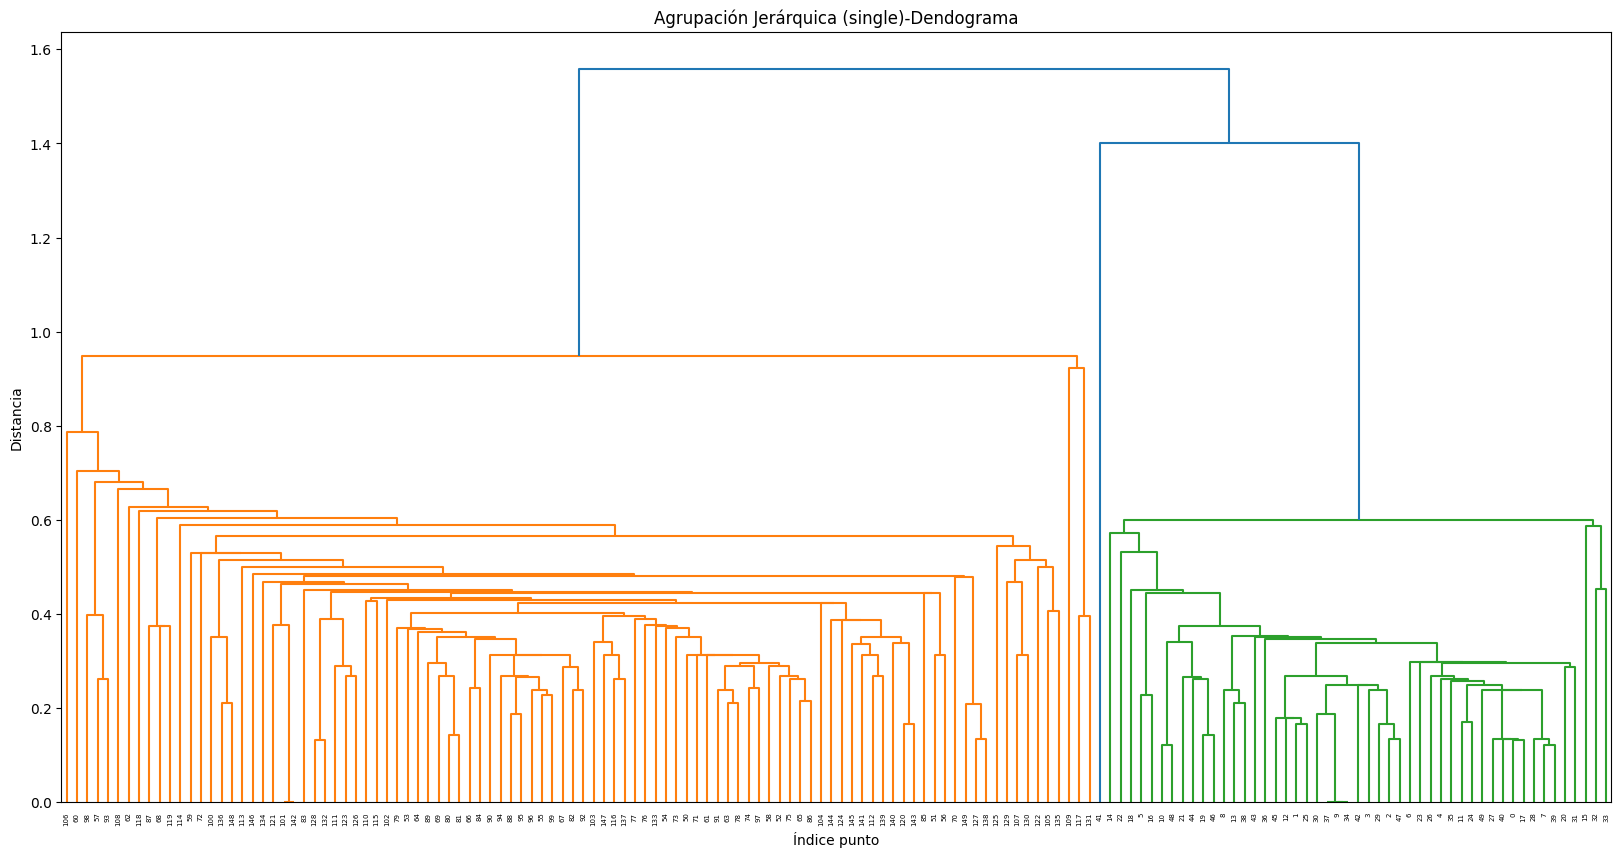

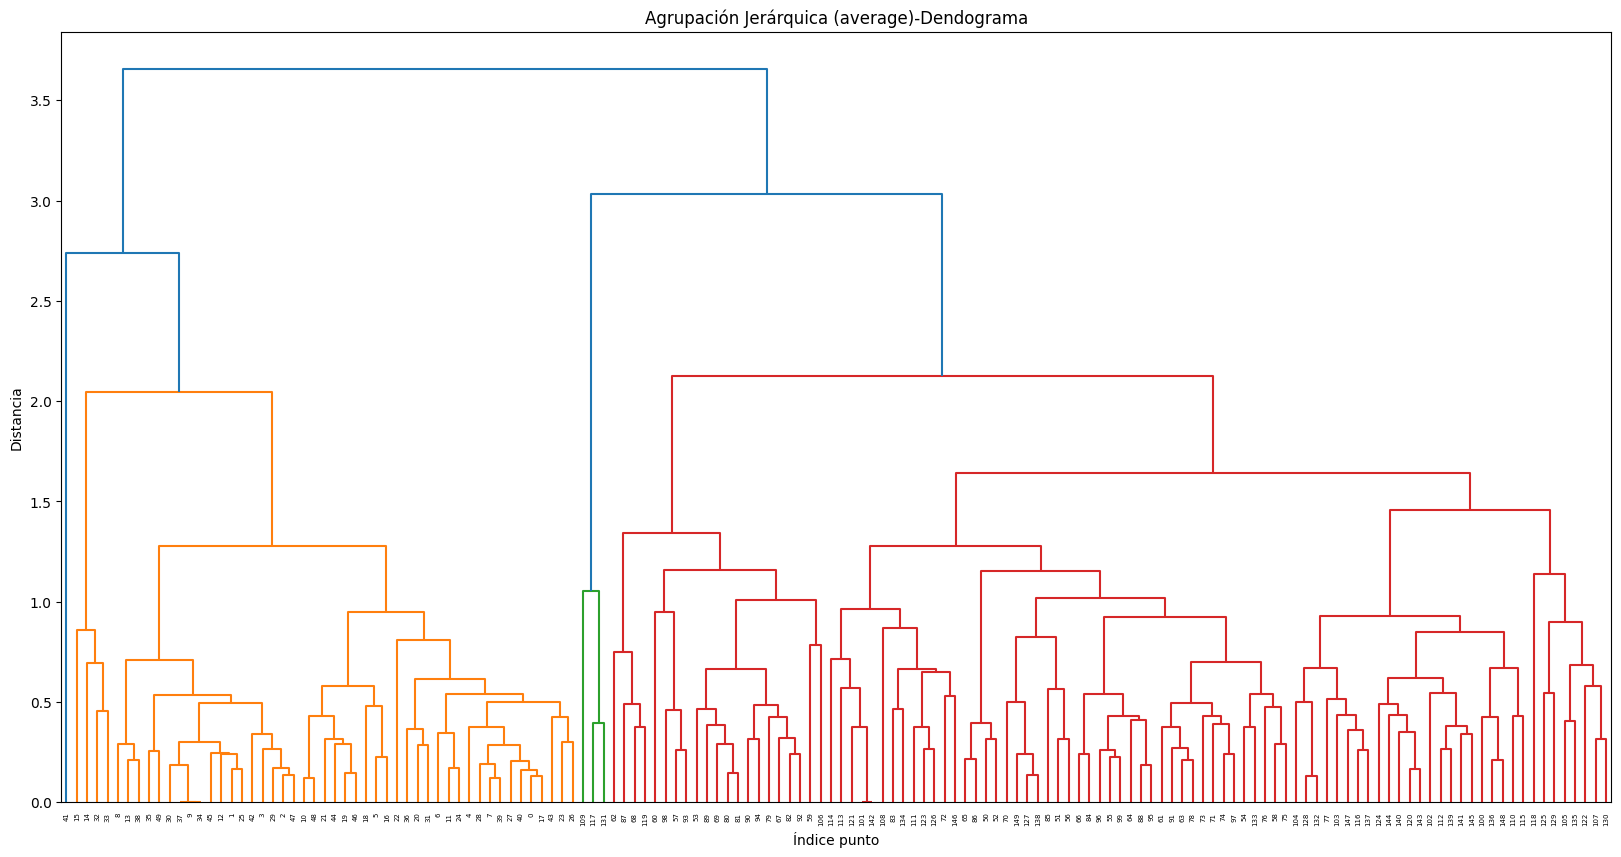

In [43]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
# Complete
linkage_complete = linkage(X_scaled, method="complete", metric="euclidean")
fig = plt.figure(figsize=(20,10))
dendrogram(linkage_complete)
plt.title("Agrupación Jerárquica (complete)-Dendograma")
plt.xlabel("Índice punto")
plt.ylabel("Distancia")
plt.show()
# Single
linkage_single = linkage(X_scaled, method="single", metric="euclidean")
fig = plt.figure(figsize=(20,10))
dendrogram(linkage_single)
plt.title("Agrupación Jerárquica (single)-Dendograma")
plt.xlabel("Índice punto")
plt.ylabel("Distancia")
plt.show()
# Average
linkage_average = linkage(X_scaled, method="average", metric="euclidean")
fig = plt.figure(figsize=(20,10))
dendrogram(linkage_average)
plt.title("Agrupación Jerárquica (average)-Dendograma")
plt.xlabel("Índice punto")
plt.ylabel("Distancia")
plt.show()